In [1]:
PROJ_NAME = "kyber_indcpa_dec_ttest"
LABEL = "fullcycle"

In [3]:
import sys
sys.path.insert(0, "../")
from host.ttest_trace_collector import TTestTraceCollector

In [4]:
trace_collector = TTestTraceCollector(proj_name=PROJ_NAME, label=LABEL, input_len=32, output_len=0)

In [5]:
trace_collector.init_target(force=True)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [6]:
trace_collector.default_setup(40E6, 12, 60000)

In [ ]:
trace_collector.build_fw()
trace_collector.program_fw()

-DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../victims_commons -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_indcpa_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_indcpa_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../victims_commons/victims_commons_util.c ../victims_commons/victims_commons_kyber.c ../../driver/cw305.c ../../driver/x2x_prng.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/star

../victims_commons/victims_commons_kyber.c: In function 'vck_masked_poly_from_seed_core':
../victims_commons/victims_commons_kyber.c:107:5: warning: implicit declaration of function 'masked_gadgets_init_q' [-Wimplicit-function-declaration]
  107 |     masked_gadgets_init_q();
      |     ^~~~~~~~~~~~~~~~~~~~~


/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .init   -j .text kyber_indcpa_dec_ttest.elf kyber_indcpa_dec_ttest.inst.bin
/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .rodata -j .data kyber_indcpa_dec_ttest.elf kyber_indcpa_dec_ttest.data.bin
python3 ../../../../sdk/toolchain/rom_generator.py kyber_indcpa_dec_ttest.inst.bin kyber_indcpa_dec_ttest.inst.mem 
python3 ../../../../sdk/toolchain/rom_generator.py kyber_indcpa_dec_ttest.data.bin kyber_indcpa_dec_ttest.data.mem 
/opt/riscv/bin/riscv64-unknown-elf-size -B kyber_indcpa_dec_ttest.elf
   text	   data	    bss	    dec	    hex	filename
   8448	      0	   9604	  18052	   4684	kyber_indcpa_dec_ttest.elf
Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/kyber_indcpa_dec_ttest/kyber_indcpa_dec_ttest.inst.bin


../fw/victims/kyber_indcpa_dec_ttest/kyber_indcpa_dec_ttest.inst.bin: 100%|██████████| 5.81k/5.81k [00:05<00:00, 1.10kB/s]
../fw/victims/kyber_indcpa_dec_ttest/kyber_indcpa_dec_ttest.data.bin:   0%|          | 0.00/2.60k [00:00<?, ?B/s]

File transmission complete for ../fw/victims/kyber_indcpa_dec_ttest/kyber_indcpa_dec_ttest.inst.bin.
Sending file: ../fw/victims/kyber_indcpa_dec_ttest/kyber_indcpa_dec_ttest.data.bin


../fw/victims/kyber_indcpa_dec_ttest/kyber_indcpa_dec_ttest.data.bin: 100%|██████████| 2.60k/2.60k [00:02<00:00, 909B/s]


File transmission complete for ../fw/victims/kyber_indcpa_dec_ttest/kyber_indcpa_dec_ttest.data.bin.
Program load complete.
Serial port closed.


# PRNG=OFF

In [9]:
trace_collector.collect_traces(N=1000, prng_off=True, overwrite=True, check_output=False, init_input=True)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

In [10]:
ttest_analysis = trace_collector.get_analysis_obj(N=1000, prng_off=True)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_cpapke_dec_ttest_N1000_prngoff1_r0_ with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_cpapke_dec_ttest_N1000_prngoff1_r1_ with 1000 traces.
s................: float64



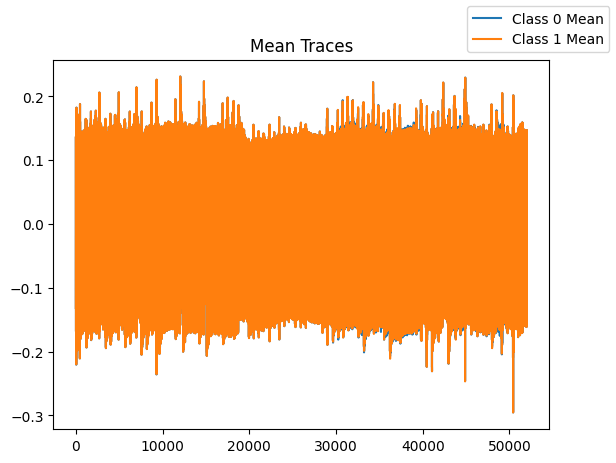

In [11]:
ttest_analysis.plot_means()

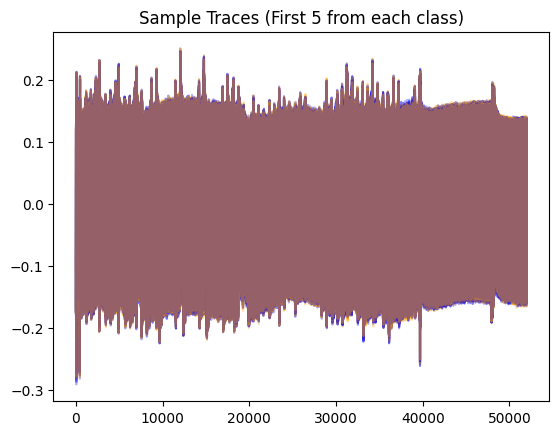

In [11]:
ttest_analysis.plot_traces()

In [14]:
ttest_analysis.run_ttest()

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


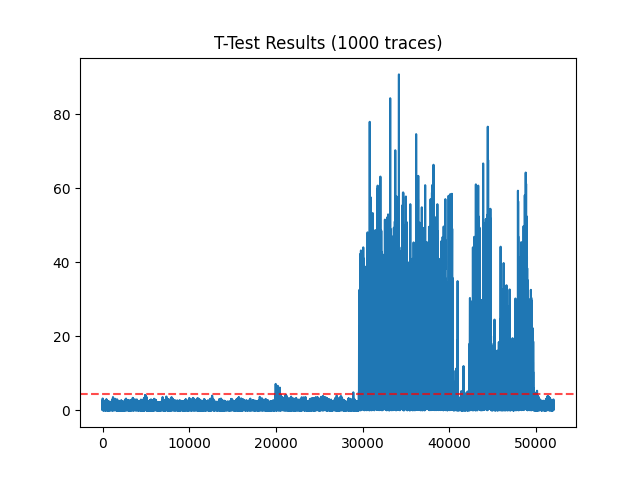

In [15]:
%matplotlib widget
ttest_analysis.plot_ttest()

# PRNG=ON

In [8]:
trace_collector.collect_traces(N=100000, prng_off=False, overwrite=True, check_output=False, init_input=False)

Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: Unable to synchronously open file (file is already open for write (may use <h5clear file> to clear file consistency flags)).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: Unable to synchronously open file (file is already open for write (may use <h5clear file> to clear file consistency flags)).


KeyboardInterrupt: 

In [9]:
ttest_analysis = trace_collector.get_analysis_obj(N=10, prng_off=False)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_cpapke_dec_ttest_N10_prngoff0_r0_polymsg_removed with 10 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_cpapke_dec_ttest_N10_prngoff0_r1_polymsg_removed with 10 traces.
s................: float64



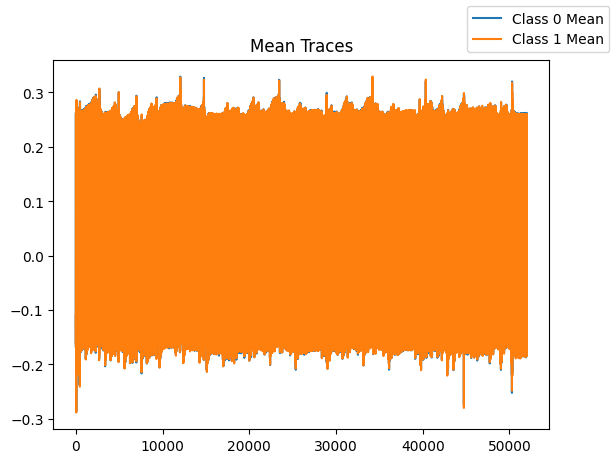

In [10]:
ttest_analysis.plot_means()

In [ ]:
ttest_analysis.plot_traces()

In [14]:
ttest_analysis.run_ttest()

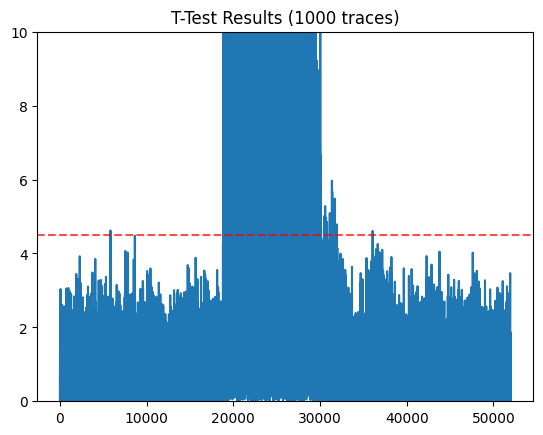

In [15]:
ttest_analysis.plot_ttest(ylimit=10)